In [1]:
# WEB DEV TEAM PLEASE DELETE BEFORE PUBLISHING - DS TEAM PLEASE KEEP IN THE FINAL VERSION OF THE USE CASE

from IPython.core.display import HTML
HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@600;700&family=Inter:wght@400;500&display=swap');
body,p,li,div{font-family:'Inter',sans-serif}
body{counter-reset:h2counter}
.usecase-header-bar,.usecase-title,.usecase-section-heading,.usecase-sub-section-heading,.usecase-sub-sub-section-heading,.usecase-unnumbered-heading{font-family:'Poppins',sans-serif}
.usecase-header-bar{padding:16px 20px;background-color:#059669;color:#fff;border-radius:6px 6px 0 0}
.usecase-title{font-size:1.9em;font-weight:800}
.usecase-details{padding-left:20px;padding-bottom:8px;padding-top:8px;font-size:1.1em;color:#121212}
.usecase-section-heading,.usecase-unnumbered-heading{font-weight:700;font-size:1.35em;color:#059669;padding:14px 4px 6px 4px;border-bottom:3px solid #2DBE6C;margin-top:10px}
.usecase-section-heading::before{content:none!important}
.usecase-sub-section-heading{font-weight:600;font-size:1.15em;color:#059669;margin-top:8px}
.usecase-sub-section-heading::before{content:none!important}
.usecase-sub-sub-section-heading{font-weight:500;font-size:1.05em;color:#059669;margin-top:6px}
.usecase-sub-sub-section-heading::before{content:none!important}
.usecase-body{font-size:1em;color:#121212;line-height:1.6;margin-bottom:8px}
.usecase-list{line-height:1.7}
.usecase-list ul,.usecase-list ol{padding-left:24px;margin-top:8px;margin-bottom:12px}
.usecase-list li{margin-bottom:6px}
.usecase-datasets{background-color:rgba(5,150,105,.06);border-left:4px solid #059669;padding:12px 20px;border-radius:0 4px 4px 0;margin-top:12px}
.usecase-datasets ul{margin-top:8px;margin-bottom:8px}
.usecase-contents a,.usecase-datasets a{color:#059669;text-decoration:none}
.usecase-datasets a{font-weight:500}
.usecase-contents a:hover,.usecase-datasets a:hover{text-decoration:underline}
.usecase-contents{line-height:1.9;padding-left:20px}
</style>
""")

<div class="usecase-header-bar"><div class="usecase-title">Parking Availability Around Melbourne Hospitality Venues 2024</div></div>

<div class="usecase-details"><b>Author: </b>Chathu Siriwardena</div>
<div class="usecase-details"><b>Created: </b>Trimester 2, 2024</div>
<div class="usecase-details"><b>Updated: </b>Trimester 2, 2026 (Sumit Adhikari)</div>
<div class="usecase-details"><b>Time to Complete:</b> 90 mins</div>
<div class="usecase-details"><b>Level: </b>Intermediate</div>
<div class="usecase-details"><b>Pre-requisite Skills: </b>Python, pandas, GeoPandas and coordinate reference systems (CRS), Matplotlib and Seaborn, clustering (K-means and DBSCAN), basic mapping concepts</div>

<div id="scenario" class="usecase-unnumbered-heading"><b>Scenario</b></div>

<div class="usecase-body">
<b>As a</b> planner at the City of Melbourne, <b>I want to</b> know how much on-street parking sits within a short walk of each cafe, restaurant and bar, <b>so that I can</b> find the places where many seats share very little parking, and focus parking and transport improvements there.
</div>

<div class="usecase-body">
<b>As a</b> venue owner, <b>I want to</b> see the parking bays and meters closest to my venue, <b>so that I can</b> give customers clear directions on where to park.
</div>

<div id="what-this-teaches" class="usecase-unnumbered-heading"><b>What this use case will teach you</b></div>

<div class="usecase-body">This use case combines four open datasets to measure how much parking each venue has nearby, then looks for patterns across the city.</div>

<div class="usecase-list">

- How to download City of Melbourne open data using the Explore API.
- How to combine two venue lists without counting the same venue twice.
- How to measure distances and count nearby parking with spatial joins.
- How to build a simple, transparent score from several measures.
- How to group venues with K-means and find dining hotspots with DBSCAN.
- How to map thousands of venues without making the notebook too large.

</div>

<div id="background" class="usecase-unnumbered-heading"><b>Background</b></div>

<div class="usecase-body">
Every year the City of Melbourne runs the Census of Land Use and Employment (CLUE). It records every cafe, restaurant, pub and bar in the municipality, along with how many seats or patrons each one can hold. On-street parking is recorded separately, as the location of every parking bay and parking meter.
</div>

<div class="usecase-body">
Putting these together shows where parking supply is thin compared with the number of seats nearby. That matters to venue owners, whose customers need somewhere to park, and to planners deciding where parking or transport improvements would help most.
</div>

<div class="usecase-body">
Two limits are worth knowing from the start. The parking data shows where bays are, not whether they are free, so "availability" here means how much parking exists nearby rather than live occupancy. And this is an observational analysis: it describes where parking is, not why it was placed there.
</div>

<div id="data-sets" class="usecase-unnumbered-heading"><b>Data Sets</b></div>

<div class="usecase-body">
The two venue datasets come from CLUE and hold one set of records per census year. We use <b>2024</b>, the latest year both share. The two parking datasets are current snapshots (last updated in 2025 and 2026), so a small number of bays may have changed since the venues were counted.
</div>

<div class="usecase-datasets">

- <a href="https://data.melbourne.vic.gov.au/explore/dataset/cafes-and-restaurants-with-seating-capacity/information/">Cafes and Restaurants with Seating Capacity</a> &mdash; one row per venue per seating type (indoor or outdoor), with its industry, address, number of seats and coordinates.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/bars-and-pubs-with-patron-capacity/information/">Bars and Pubs with Patron Capacity</a> &mdash; one row per bar or pub, with its address, patron capacity and coordinates.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/on-street-parking-bays/information/">On-street Parking Bays</a> &mdash; one row per parking bay, with its street segment and coordinates.
- <a href="https://data.melbourne.vic.gov.au/explore/dataset/on-street-car-parking-meters-with-location/information/">On-street Car Parking Meters with Location</a> &mdash; one row per parking meter, with its location description and coordinates.

</div>

<div class="usecase-unnumbered-heading"><b>Contents</b></div>

<div class="usecase-contents">

1. <a href="#section-1">Setting up and loading the data</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.1. <a href="#sub-1-1">Importing the libraries</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;1.2. <a href="#sub-1-2">Using the API to call the data from the Melbourne Open Data Site</a><br>
2. <a href="#section-2">Checking data quality</a><br>
3. <a href="#section-3">Preparing the data for analysis</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.1. <a href="#sub-3-1">Keeping the 2024 census</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.2. <a href="#sub-3-2">Building one row per venue</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.3. <a href="#sub-3-3">Combining cafes and bars without double counting</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;3.4. <a href="#sub-3-4">Preparing the parking layers</a><br>
4. <a href="#section-4">Exploring the venues</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.1. <a href="#sub-4-1">What kinds of venues are there?</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.2. <a href="#sub-4-2">How big are the venues?</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;4.3. <a href="#sub-4-3">Where are the venues?</a><br>
5. <a href="#section-5">Measuring the parking around each venue</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.1. <a href="#sub-5-1">Finding the nearest parking bay</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.2. <a href="#sub-5-2">Counting bays and meters within walking distance</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.3. <a href="#sub-5-3">Building a parking access score</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.4. <a href="#sub-5-4">Comparing parking access across areas</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;5.5. <a href="#sub-5-5">Do bigger venues have more parking nearby?</a><br>
6. <a href="#section-6">Grouping venues with clustering</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.1. <a href="#sub-6-1">Parking groups with K-means</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;6.2. <a href="#sub-6-2">Dining hotspots with DBSCAN</a><br>
7. <a href="#section-7">Mapping the results</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.1. <a href="#sub-7-1">Parking access across the city</a><br>
&nbsp;&nbsp;&nbsp;&nbsp;7.2. <a href="#sub-7-2">Looking up the parking near one venue</a>

</div>

<div id="section-1" class="usecase-section-heading"><b>1. Setting up and loading the data</b></div>

<div class="usecase-body">We import the libraries, then download all four datasets straight from the API.</div>

<div id="sub-1-1" class="usecase-sub-section-heading"><b>1.1. Importing the libraries</b></div>

<div class="usecase-body">Each library has one job here: pandas for tables, GeoPandas for anything involving location, scikit-learn for clustering, folium for the interactive maps, and matplotlib and seaborn for the charts.</div>

In [2]:
import re                          # pulling street names out of addresses
from io import StringIO            # lets pandas read the API response as if it were a file

import numpy as np                 # numbers and arrays
import pandas as pd                # tables
import geopandas as gpd            # tables that understand location
import matplotlib.pyplot as plt    # charts
from matplotlib.ticker import PercentFormatter
import seaborn as sns              # nicer looking charts
import requests                    # calling the API
import folium                      # interactive maps
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# The colour order used throughout this notebook, taken from the MOP style guide.
GREEN, PURPLE, ORANGE, BLUE = "#059669", "#9333EA", "#F97316", "#2563EB"

DARK = "#121212"   # outlines and text on the maps

# Each parking access category keeps the same colour in every chart and map.
CATEGORY_COLOURS = {"High": GREEN, "Moderate": PURPLE, "Low": ORANGE}

# A Coordinate Reference System (CRS) is the system used to say where
# something is on Earth. EPSG numbers are the catalogue codes for those
# systems. Section 3.4 explains why we need two.
CRS_DEGREES = "EPSG:4326"   # latitude and longitude, as the API supplies them
CRS_METRES = "EPSG:7855"    # Melbourne's local grid, measured in metres

sns.set_style("whitegrid")

<div id="sub-1-2" class="usecase-sub-section-heading"><b>1.2. Using the API to call the data from the Melbourne Open Data Site</b></div>

<div class="usecase-body">One small function handles all four downloads. It asks the API for the whole dataset as CSV and hands back a DataFrame.</div>

In [3]:
def fetch_melbourne_dataset(dataset_id):
    """Download a full City of Melbourne dataset and return it as a DataFrame.

    dataset_id is the name shown in the dataset's URL, for example 'on-street-parking-bays'.
    """
    base_url = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/"
    export_url = f"{base_url}{dataset_id}/exports/csv"

    params = {
        "select": "*",
        "limit": -1,        # -1 means every record, not just the first page
        "lang": "en",
        "timezone": "UTC",
    }

    response = requests.get(export_url, params=params, timeout=180)
    response.raise_for_status()   # stop immediately with a clear error if the call failed

    # The export endpoint returns semicolon-separated CSV.
    return pd.read_csv(StringIO(response.content.decode("utf-8")), delimiter=";")

<div class="usecase-body">Now we load the four datasets. This usually takes less than a minute.</div>

In [4]:
cafes = fetch_melbourne_dataset("cafes-and-restaurants-with-seating-capacity")
bars = fetch_melbourne_dataset("bars-and-pubs-with-patron-capacity")
parking_bays = fetch_melbourne_dataset("on-street-parking-bays")
parking_meters = fetch_melbourne_dataset("on-street-car-parking-meters-with-location")

datasets = {
    "Cafes and restaurants": cafes,
    "Bars and pubs": bars,
    "Parking bays": parking_bays,
    "Parking meters": parking_meters,
}

for name, table in datasets.items():
    print(f"{name:<22}: {len(table):>6,} rows x {table.shape[1]} columns")

Cafes and restaurants : 66,356 rows x 15 columns
Bars and pubs         :  5,304 rows x 12 columns
Parking bays          : 29,053 rows x 7 columns
Parking meters        :  1,404 rows x 9 columns


<div class="usecase-body">
<b>What this shows:</b> the size of each dataset.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the two venue datasets hold every census year since 2002, so they have far more rows than there are venues trading today. Section 3 narrows them down to a single year.
</div>

<div id="section-2" class="usecase-section-heading"><b>2. Checking data quality</b></div>

<div class="usecase-body">Before analysing anything we check each table for duplicate rows and missing values, and confirm which years the venue data covers.</div>

In [5]:
for name, table in datasets.items():
    missing = table.isna().sum()
    missing = missing[missing > 0]
    missing_text = ", ".join(f"{column} ({count:,})" for column, count in missing.items()) or "none"
    print(f"{name:<22} duplicate rows: {table.duplicated().sum()}   missing values: {missing_text}")

print()
for name, table in [("Cafe", cafes), ("Bar", bars)]:
    no_location = table.loc[table["latitude"].isna(), "census_year"]
    print(f"{name} rows without coordinates: {len(no_location)} "
          f"(census years {no_location.min()} to {no_location.max()})")

print()
print(f"Cafe census years : {cafes['census_year'].min()} to {cafes['census_year'].max()}")
print(f"Bar census years  : {bars['census_year'].min()} to {bars['census_year'].max()}")
print(f"Parking bays last updated: {parking_bays['lastupdated'].min()} to {parking_bays['lastupdated'].max()}")

Cafes and restaurants  duplicate rows: 0   missing values: longitude (527), latitude (527), location (527)
Bars and pubs          duplicate rows: 0   missing values: longitude (20), latitude (20), location (20)
Parking bays           duplicate rows: 0   missing values: kerbsideid (23,981)
Parking meters         duplicate rows: 0   missing values: creditcard (307)

Cafe rows without coordinates: 527 (census years 2002 to 2016)
Bar rows without coordinates: 20 (census years 2003 to 2016)

Cafe census years : 2002 to 2024
Bar census years  : 2002 to 2024
Parking bays last updated: 2025-06-03 to 2026-03-31


<div class="usecase-body">
<b>What this shows:</b> whether any table has duplicate rows or gaps, and the period each dataset covers.
</div>

<div class="usecase-body">
<b>Why it matters:</b> there are no duplicate rows. Some venue rows have no coordinates, but they all come from older census years, so they do not affect the 2024 analysis. Section 3.1 still removes any that appear, so the notebook keeps working if the data changes. The other gaps are in <code>kerbsideid</code> (a sensor id that most bays do not have) and <code>creditcard</code> (a meter payment flag), and neither column is used. The census years confirm that 2024 is the latest year in both venue datasets.
</div>

<div id="section-3" class="usecase-section-heading"><b>3. Preparing the data for analysis</b></div>

<div class="usecase-body">We narrow the venue data to one year, turn it into one row per venue, merge cafes and bars into a single list, and get the parking layers ready for measuring distances.</div>

<div id="sub-3-1" class="usecase-sub-section-heading"><b>3.1. Keeping the 2024 census</b></div>

<div class="usecase-body">The venue datasets repeat most venues once per census year. We keep only 2024, the year this use case is about. The year is fixed on purpose, so the results stay the same when the notebook is run again after a new census is published.</div>

In [6]:
CENSUS_YEAR = 2024   # the latest year both venue datasets share (see section 2)

# Stop with a clear message if a future refresh removes this year.
assert CENSUS_YEAR in set(cafes["census_year"]) and CENSUS_YEAR in set(bars["census_year"]), \
    f"{CENSUS_YEAR} is missing from one of the venue datasets"

cafes_year = cafes[cafes["census_year"] == CENSUS_YEAR]
bars_year = bars[bars["census_year"] == CENSUS_YEAR]

# Rows without coordinates cannot be measured or mapped, so we drop any that appear.
no_location = cafes_year["latitude"].isna().sum() + bars_year["latitude"].isna().sum()
cafes_year = cafes_year.dropna(subset=["latitude", "longitude"]).copy()
bars_year = bars_year.dropna(subset=["latitude", "longitude"]).copy()

print(f"Cafe and restaurant rows in {CENSUS_YEAR}: {len(cafes_year):,}")
print(f"Bar and pub rows in {CENSUS_YEAR}        : {len(bars_year):,}")
print(f"Rows removed for missing coordinates: {no_location}")

Cafe and restaurant rows in 2024: 3,249
Bar and pub rows in 2024        : 304
Rows removed for missing coordinates: 0


<div class="usecase-body">
<b>What this shows:</b> how many rows remain for 2024 in each venue dataset, and how many had to be removed.
</div>

<div class="usecase-body">
<b>Why it matters:</b> mixing years would count the same venue several times and include venues that have since closed. No 2024 rows are missing coordinates, so nothing is lost here.
</div>

<div id="sub-3-2" class="usecase-sub-section-heading"><b>3.2. Building one row per venue</b></div>

<div class="usecase-body">The cafe dataset lists indoor and outdoor seating as separate rows, so a venue with both appears twice. We add the two together to get each venue's total seats.</div>

<div class="usecase-body">A venue is identified by its building (<code>property_id</code>), trading name and business address together. One building can hold many businesses, and a chain can use the same name at many addresses, so no single column is enough.</div>

In [7]:
VENUE_KEY = ["property_id", "trading_name", "business_address"]

print("Seating rows by type:")
print(cafes_year["seating_type"].value_counts().to_string())

cafe_venues = (
    cafes_year
    .groupby(VENUE_KEY, as_index=False)
    .agg(
        area=("clue_small_area", "first"),
        industry=("industry_anzsic4_description", "first"),
        seats=("number_of_seats", "sum"),          # indoor + outdoor
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
    )
)

# Why not group on location instead? Venues in the same building share
# coordinates, so grouping on longitude would merge separate businesses.
shared_location = cafe_venues.duplicated(["latitude", "longitude"], keep=False).sum()

print(f"\n{len(cafes_year):,} seating rows became {len(cafe_venues):,} venues.")
print(f"{shared_location:,} of these venues share their exact coordinates with another venue.")

Seating rows by type:
seating_type
Seats - Indoor     2175
Seats - Outdoor    1074

3,249 seating rows became 2,248 venues.
1,320 of these venues share their exact coordinates with another venue.


<div class="usecase-body">
<b>What this shows:</b> how the seating rows split between indoor and outdoor, how many venues they add up to, and how many venues share a location with another venue.
</div>

<div class="usecase-body">
<b>Why it matters:</b> many venues share a building, and therefore a location. Grouping on coordinates would merge those separate businesses and inflate their seat counts, which is why the venue key uses the building, name and address instead.
</div>

<div id="sub-3-3" class="usecase-sub-section-heading"><b>3.3. Combining cafes and bars without double counting</b></div>

<div class="usecase-body">Many pubs and bars also appear in the cafe dataset, because they serve food. To avoid counting them twice, we only add a bar if the same building does not already list a venue with the same trading name. For bars we use patron capacity as the equivalent of seats.</div>

<div class="usecase-body">Matching on longitude alone is a common shortcut, but it treats every business in a building as the same venue. The code below shows how many bars that shortcut would wrongly drop.</div>

In [8]:
def match_key(table):
    """Building id plus a tidied trading name, used to find the same venue in both lists."""
    return list(zip(table["property_id"], table["trading_name"].str.strip().str.lower()))

cafe_keys = set(match_key(cafe_venues))
bars_year["already_listed"] = [key in cafe_keys for key in match_key(bars_year)]
new_bars = bars_year[~bars_year["already_listed"]]

# For comparison only: the longitude shortcut.
longitude_match = bars_year["longitude"].isin(cafe_venues["longitude"])
wrongly_dropped = (longitude_match & ~bars_year["already_listed"]).sum()

print(f"Bars and pubs in {CENSUS_YEAR}                  : {len(bars_year)}")
print(f"Already in the cafe list (same building + name): {bars_year['already_listed'].sum()}")
print(f"New venues added from the bar list             : {len(new_bars)}")
print(f"Matching on longitude would drop {longitude_match.sum()} bars, {wrongly_dropped} of them wrongly.")

bar_venues = (
    new_bars
    .rename(columns={"clue_small_area": "area", "number_of_patrons": "seats"})
    .assign(industry="Pubs, Taverns and Bars")
    [cafe_venues.columns]
)
venues = pd.concat([cafe_venues, bar_venues], ignore_index=True)

# Keep the four biggest industries and group the long tail as "Other",
# so the charts stay readable.
MAIN_INDUSTRIES = ["Cafes and Restaurants", "Takeaway Food Services",
                   "Pubs, Taverns and Bars", "Accommodation"]
venues["industry_group"] = venues["industry"].where(venues["industry"].isin(MAIN_INDUSTRIES), "Other")

print(f"\nFinal list: {len(venues):,} venues with {venues['seats'].sum():,} seats in total.")

Bars and pubs in 2024                  : 304
Already in the cafe list (same building + name): 166
New venues added from the bar list             : 138
Matching on longitude would drop 247 bars, 81 of them wrongly.

Final list: 2,386 venues with 215,723 seats in total.


<div class="usecase-body">
<b>What this shows:</b> how many bars were already in the cafe list, how many were added, and how many the longitude shortcut would have lost.
</div>

<div class="usecase-body">
<b>Why it matters:</b> every later figure depends on this list being right. Matching on building and name keeps each venue exactly once, while the shortcut would have removed dozens of real bars simply because they share a building with a cafe.
</div>

<div id="sub-3-4" class="usecase-sub-section-heading"><b>3.4. Preparing the parking layers</b></div>

<div class="usecase-body">Parking bays are the actual spaces, so they measure parking supply. A meter is a payment machine that covers several bays, so meters are not counted as spaces. We use them only as a sign that the parking nearby is paid.</div>

<div class="usecase-body">Latitude and longitude are angles, not distances, so we convert every layer to a grid measured in metres before measuring anything. EPSG codes simply identify coordinate systems: <b>EPSG:4326</b> is latitude and longitude, and <b>EPSG:7855</b> is Melbourne's local metre grid.</div>

In [9]:
bays = parking_bays[["roadsegmentdescription", "latitude", "longitude"]].rename(
    columns={"roadsegmentdescription": "street_segment"})
meters = parking_meters[["location_description", "latitude", "longitude"]].rename(
    columns={"location_description": "meter_location"})


def to_metres(table):
    """Turn a table with latitude and longitude columns into a GeoDataFrame measured in metres."""
    points = gpd.points_from_xy(table["longitude"], table["latitude"])
    return gpd.GeoDataFrame(table, geometry=points, crs=CRS_DEGREES).to_crs(CRS_METRES)


venues_m = to_metres(venues)
bays_m = to_metres(bays)
meters_m = to_metres(meters)

print(f"Venues        : {len(venues_m):,}")
print(f"Parking bays  : {len(bays_m):,}")
print(f"Parking meters: {len(meters_m):,}")

Venues        : 2,386
Parking bays  : 29,053
Parking meters: 1,404


<div class="usecase-body">
<b>What this shows:</b> the number of venues, bays and meters ready for the spatial analysis.
</div>

<div class="usecase-body">
<b>Why it matters:</b> all three layers now share the same metre grid, so any distance measured between them is a real distance on the ground.
</div>

<div id="section-4" class="usecase-section-heading"><b>4. Exploring the venues</b></div>

<div class="usecase-body">A quick look at what the venues are, how big they are and where they sit, before bringing parking into the picture.</div>

<div id="sub-4-1" class="usecase-sub-section-heading"><b>4.1. What kinds of venues are there?</b></div>

<div class="usecase-body">The number of venues in each industry group.</div>

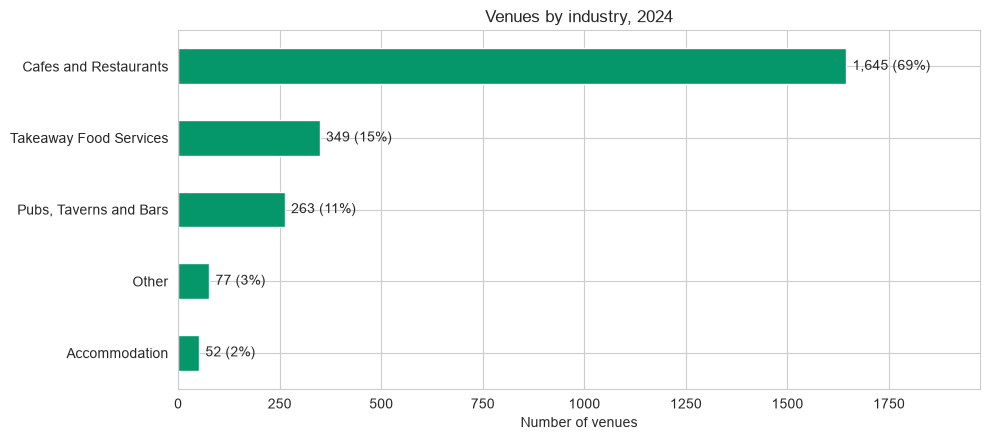

'Other' combines 29 smaller industries, such as bakeries, catering and clubs.


In [10]:
industry_counts = venues["industry_group"].value_counts().sort_values()

plt.figure(figsize=(10, 4.5))
ax = industry_counts.plot(kind="barh", color=GREEN)
for bar, count in zip(ax.patches, industry_counts):
    ax.text(bar.get_width() + 15, bar.get_y() + bar.get_height() / 2,
            f"{count:,} ({count / len(venues):.0%})", va="center")
plt.title(f"Venues by industry, {CENSUS_YEAR}")
plt.xlabel("Number of venues")
plt.ylabel("")
plt.xlim(0, industry_counts.max() * 1.2)
plt.tight_layout()
plt.show()

other_count = venues.loc[venues["industry_group"] == "Other", "industry"].nunique()
print(f"'Other' combines {other_count} smaller industries, such as bakeries, catering and clubs.")

<div class="usecase-body">
<b>What this shows:</b> how the venues split across industry groups.
</div>

<div class="usecase-body">
<b>Why it matters:</b> cafes and restaurants make up most of the list, so they will drive most of the results. Takeaway shops and pubs are the next largest groups.
</div>

<div id="sub-4-2" class="usecase-sub-section-heading"><b>4.2. How big are the venues?</b></div>

<div class="usecase-body">The number of venues in each seating range.</div>

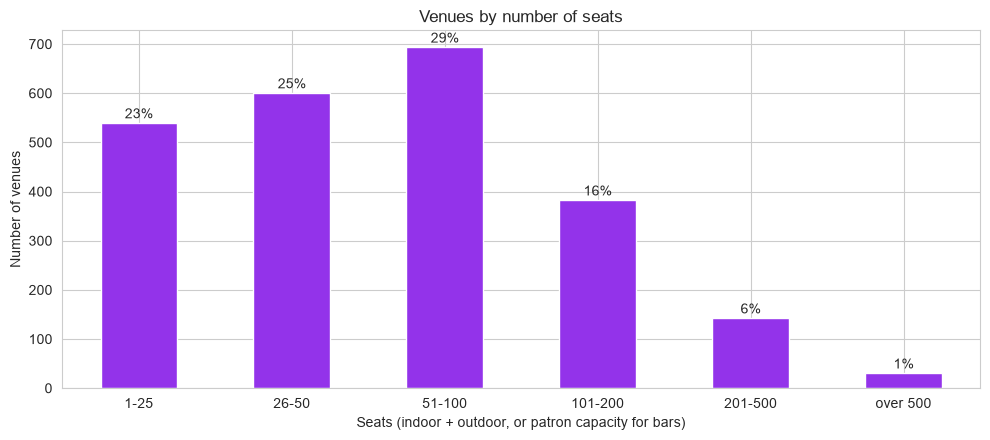

Typical venue: 55 seats. Largest: 4,970 seats.


In [11]:
seat_bands = pd.cut(
    venues["seats"],
    bins=[0, 25, 50, 100, 200, 500, float("inf")],
    labels=["1-25", "26-50", "51-100", "101-200", "201-500", "over 500"],
)
band_counts = seat_bands.value_counts().sort_index()

plt.figure(figsize=(10, 4.5))
ax = band_counts.plot(kind="bar", color=PURPLE)
for bar, count in zip(ax.patches, band_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{count / len(venues):.0%}", ha="center")
plt.title("Venues by number of seats")
plt.xlabel("Seats (indoor + outdoor, or patron capacity for bars)")
plt.ylabel("Number of venues")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"Typical venue: {venues['seats'].median():.0f} seats. Largest: {venues['seats'].max():,} seats.")

<div class="usecase-body">
<b>What this shows:</b> the spread of venue sizes, from small cafes to large pubs and function venues.
</div>

<div class="usecase-body">
<b>Why it matters:</b> most venues are small, but a few hold hundreds or thousands of people. That long tail is why section 5 compares size and parking using rankings rather than raw values.
</div>

<div id="sub-4-3" class="usecase-sub-section-heading"><b>4.3. Where are the venues?</b></div>

<div class="usecase-body">The number of venues in each CLUE small area.</div>

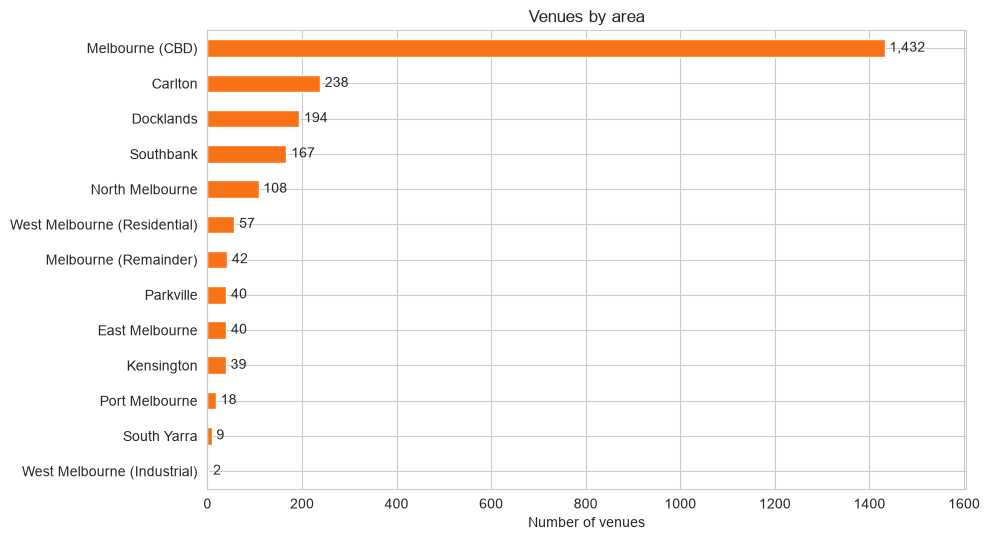

In [12]:
area_counts = venues["area"].value_counts().sort_values()

plt.figure(figsize=(10, 5.5))
ax = area_counts.plot(kind="barh", color=ORANGE)
for bar, count in zip(ax.patches, area_counts):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height() / 2, f"{count:,}", va="center")
plt.title("Venues by area")
plt.xlabel("Number of venues")
plt.ylabel("")
plt.xlim(0, area_counts.max() * 1.12)
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> how many venues sit in each part of the city.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the CBD holds most of the venues, followed by Carlton, Docklands and Southbank. Areas with only a handful of venues give less reliable results, which is worth remembering when comparing areas in section 5.
</div>

<div id="section-5" class="usecase-section-heading"><b>5. Measuring the parking around each venue</b></div>

<div class="usecase-body">This is the part that answers the scenario. For every venue we measure how far away the nearest bay is and how much parking is within a short walk, then combine those measures into one score.</div>

<div id="sub-5-1" class="usecase-sub-section-heading"><b>5.1. Finding the nearest parking bay</b></div>

<div class="usecase-body">A nearest-neighbour spatial join pairs each venue with its closest parking bay and records the distance in metres.</div>

In [13]:
nearest = gpd.sjoin_nearest(
    venues_m,
    bays_m[["street_segment", "geometry"]],
    how="left",
    distance_col="nearest_bay_m",
)

# sjoin_nearest returns one row per tie when two bays are equally close.
# Keeping the first row for each venue leaves exactly one row each.
nearest = nearest[~nearest.index.duplicated(keep="first")]
venues_m["nearest_bay_street"] = nearest["street_segment"]
venues_m["nearest_bay_m"] = nearest["nearest_bay_m"]

distances = venues_m["nearest_bay_m"]
print("Distance from each venue to its nearest parking bay")
print(f"  closest  : {distances.min():>4.0f} m")
print(f"  typical  : {distances.median():>4.0f} m")
print(f"  furthest : {distances.max():>4.0f} m")
print(f"\n{(distances > 100).sum():,} venues ({(distances > 100).mean():.0%}) have no bay within 100 m.")

Distance from each venue to its nearest parking bay
  closest  :    5 m
  typical  :   32 m
  furthest :  668 m

167 venues (7%) have no bay within 100 m.


<div class="usecase-body">
<b>What this shows:</b> the closest, typical and furthest distance from a venue to its nearest parking bay.
</div>

<div class="usecase-body">
<b>Why it matters:</b> this is the first real link between the venues and the parking data. As a guide, 100 m is about a one minute walk and 200 m about two to three minutes.
</div>

<div id="sub-5-2" class="usecase-sub-section-heading"><b>5.2. Counting bays and meters within walking distance</b></div>

<div class="usecase-body">The single nearest bay says nothing about how much parking there is overall, so we also count the bays within 100 m and 200 m of each venue, and the meters within 200 m.</div>

In [14]:
SHORT_WALK_M = 100    # about a one minute walk
LONGER_WALK_M = 200   # about a two to three minute walk


def count_within(points, targets, radius_m):
    """For each point, count how many targets lie within radius_m metres."""
    # The spatial index finds every close (point, target) pair in one step,
    # which is much faster than measuring each distance separately.
    point_positions, _ = targets.sindex.query(points.geometry, predicate="dwithin", distance=radius_m)
    return np.bincount(point_positions, minlength=len(points))


venues_m["bays_within_100m"] = count_within(venues_m, bays_m, SHORT_WALK_M)
venues_m["bays_within_200m"] = count_within(venues_m, bays_m, LONGER_WALK_M)
venues_m["meters_within_200m"] = count_within(venues_m, meters_m, LONGER_WALK_M)

counts = venues_m[["bays_within_100m", "bays_within_200m", "meters_within_200m"]]
summary = pd.DataFrame({
    "bottom 10% of venues": counts.quantile(0.10),
    "typical venue": counts.median(),
    "top 10% of venues": counts.quantile(0.90),
    "venues with none": (counts == 0).sum(),
}).round(0).astype(int)
print(summary.to_string())

# Silent check: a venue whose nearest bay is over 200 m away cannot have a bay within 200 m.
assert ((venues_m["nearest_bay_m"] > LONGER_WALK_M) == (venues_m["bays_within_200m"] == 0)).all()

                    bottom 10% of venues  typical venue  top 10% of venues  venues with none
bays_within_100m                       8             48                 97               167
bays_within_200m                      61            196                360                54
meters_within_200m                     2             15                 23               185


<div class="usecase-body">
<b>What this shows:</b> how many bays and meters a typical venue has nearby, how much that varies, and how many venues have none at all.
</div>

<div class="usecase-body">
<b>Why it matters:</b> counts capture the difference between a venue beside one lonely bay and a venue on a street lined with them. The two measures agree with each other: the check at the end confirms that every venue with no bay inside 200 m is also one whose nearest bay is further than 200 m away.
</div>

<div id="sub-5-3" class="usecase-sub-section-heading"><b>5.3. Building a parking access score</b></div>

<div class="usecase-body">
To compare venues easily we combine the three parking measures into one <b>parking access score</b> from 0 to 100. It is a rule-based index, built in three steps:
</div>

<div class="usecase-list">

- Each measure is turned into a <b>percentile rank</b> between 0 and 1: the share of venues that this venue matches or beats. This puts counts and distances on the same scale and stops a few extreme values from dominating. Distance is flipped, because a shorter walk is better.
- The ranks are combined with fixed weights: bays within 200 m (40%), bays within 100 m (30%) and distance to the nearest bay (30%).
- Venues scoring above 67 are rated <b>High</b>, 33 to 67 <b>Moderate</b>, and below 33 <b>Low</b>.

</div>

<div class="usecase-body">
Because the ranks compare venues with each other, the score is relative: <i>Low</i> means less parking than most venues in the city, not "no parking". Seats and industry are left out on purpose. The score measures parking supply only, and section 5.5 compares it with venue size separately. Including seats would give a large venue a better parking score just for being large.
</div>

<div class="usecase-body">
We also do <b>not</b> train a model to predict this score. The score is calculated directly from these three measures, so a model given the same measures would simply re-learn the formula and report near-perfect accuracy that tells us nothing new. Section 6 uses clustering instead, which looks for patterns without being told the answer.
</div>

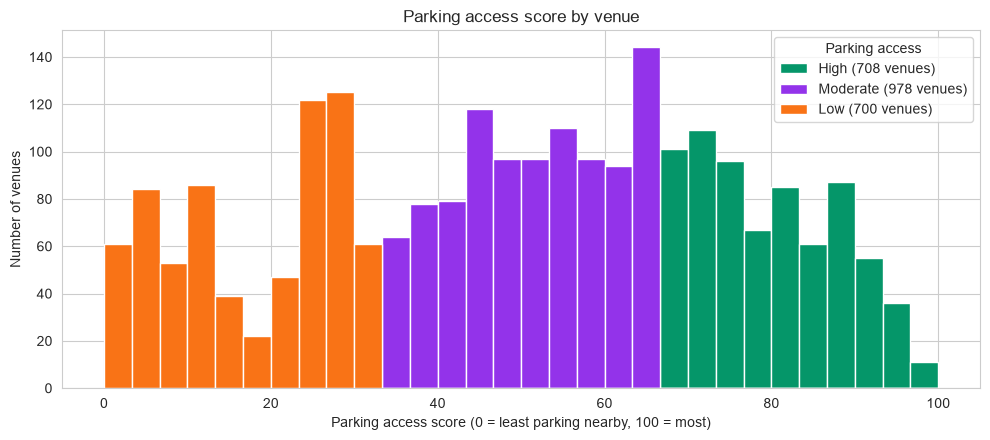

In [15]:
# How much each measure counts towards the score (the weights add up to 1).
SCORE_WEIGHTS = {
    "bays_within_200m": 0.4,
    "bays_within_100m": 0.3,
    "nearest_bay_m": 0.3,
}

# rank(pct=True) gives each venue the share of venues it matches or beats.
# Distance is flipped, because a shorter walk is better.
ranks = pd.DataFrame({
    "bays_within_200m": venues_m["bays_within_200m"].rank(pct=True),
    "bays_within_100m": venues_m["bays_within_100m"].rank(pct=True),
    "nearest_bay_m": 1 - venues_m["nearest_bay_m"].rank(pct=True),
})

venues_m["access_score"] = 100 * sum(weight * ranks[column] for column, weight in SCORE_WEIGHTS.items())
venues_m["access_category"] = pd.cut(
    venues_m["access_score"],
    bins=[0, 100 / 3, 200 / 3, 100],
    labels=["Low", "Moderate", "High"],
    include_lowest=True,
)

plt.figure(figsize=(10, 4.5))
bins = np.linspace(0, 100, 31)
for category, colour in CATEGORY_COLOURS.items():
    scores = venues_m.loc[venues_m["access_category"] == category, "access_score"]
    plt.hist(scores, bins=bins, color=colour, label=f"{category} ({len(scores):,} venues)")
plt.title("Parking access score by venue")
plt.xlabel("Parking access score (0 = least parking nearby, 100 = most)")
plt.ylabel("Number of venues")
plt.legend(title="Parking access")
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> how the venues spread across the score, coloured by the category each one falls into.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the score turns three separate measures into one number that is easy to rank, map and explain. Every step is visible in the code, so anyone can check or change the weights.
</div>

<div id="sub-5-4" class="usecase-sub-section-heading"><b>5.4. Comparing parking access across areas</b></div>

<div class="usecase-body">The share of venues in each category, area by area. Areas at the top of the chart have the largest share of Low access venues.</div>

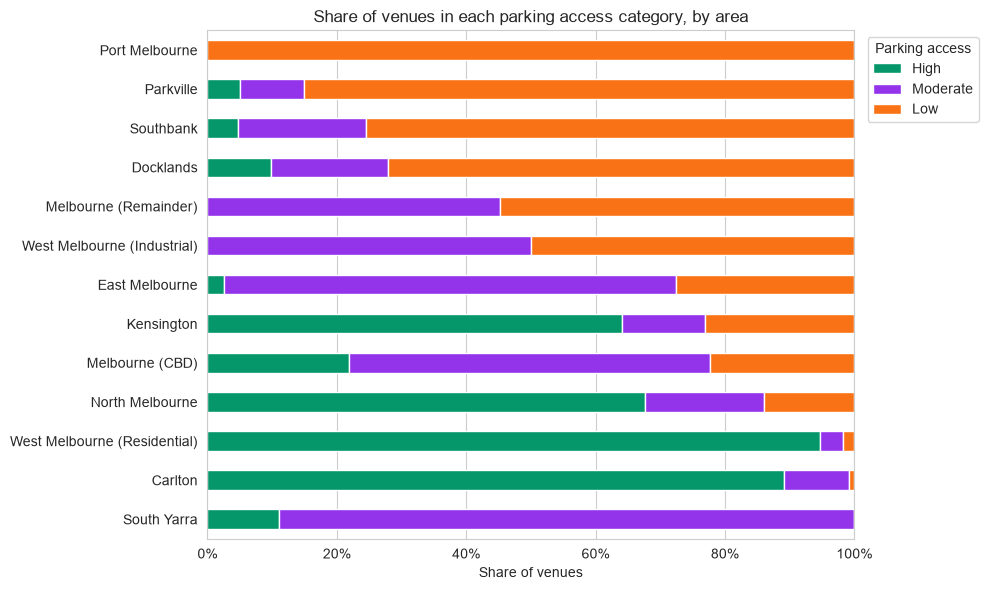

,venues,median_score,median_nearest_bay_m,median_bays_within_200m,median_meters_within_200m,low_access_%,high_access_%
area,,,,,,,
Parkville,40,5,131,22,1,85,5
Port Melbourne,18,5,116,25,0,100,0
Southbank,167,12,67,59,4,75,5
West Melbourne (Industrial),2,23,73,62,0,50,0
Docklands,194,25,47,78,8,72,10
Melbourne (Remainder),42,26,52,105,7,55,0
East Melbourne,40,44,41,144,10,28,2
Melbourne (CBD),1432,52,31,198,16,22,22
South Yarra,9,63,24,252,5,0,11


In [16]:
area_access = pd.crosstab(venues_m["area"], venues_m["access_category"], normalize="index")
area_access = area_access[["High", "Moderate", "Low"]].sort_values("Low")

ax = area_access.plot(kind="barh", stacked=True, figsize=(10, 6),
                      color=[CATEGORY_COLOURS[c] for c in area_access.columns])
ax.xaxis.set_major_formatter(PercentFormatter(1))
plt.title("Share of venues in each parking access category, by area")
plt.xlabel("Share of venues")
plt.ylabel("")
plt.legend(title="Parking access", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

area_table = venues_m.groupby("area").agg(
    venues=("access_score", "size"),
    median_score=("access_score", "median"),
    median_nearest_bay_m=("nearest_bay_m", "median"),
    median_bays_within_200m=("bays_within_200m", "median"),
    median_meters_within_200m=("meters_within_200m", "median"),
)
area_table["low_access_%"] = 100 * area_access["Low"]
area_table["high_access_%"] = 100 * area_access["High"]
area_table.round(0).astype(int).sort_values("median_score")

<div class="usecase-body">
<b>What this shows:</b> how parking access differs between areas, first as shares of each category and then as a table of typical values and the share of Low and High access venues in each area.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it shows where the parking shortfall is concentrated. Parkville, Port Melbourne, Southbank and Docklands have the weakest access, while Carlton, West Melbourne (Residential), Kensington and North Melbourne have the strongest, and the CBD sits in between. The meter column adds another angle: where a typical venue has many meters nearby, as in the CBD and Carlton, most nearby parking is likely to be paid. Areas with only a few venues, such as West Melbourne (Industrial) and South Yarra, are too small to compare reliably.
</div>

<div id="sub-5-5" class="usecase-sub-section-heading"><b>5.5. Do bigger venues have more parking nearby?</b></div>

<div class="usecase-body">If parking supply followed demand, bigger venues would tend to have more parking nearby. We test that with a Spearman correlation, which compares rankings and so is not thrown off by the few very large venues seen in section 4.2.</div>

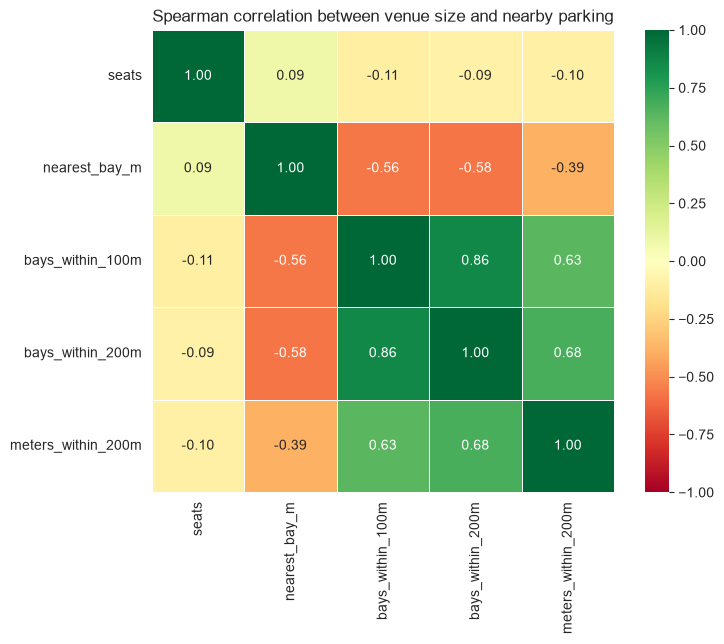

Seats vs bays within 200 m       : -0.09
Seats vs distance to nearest bay : 0.09


In [17]:
analysis_columns = ["seats", "nearest_bay_m", "bays_within_100m", "bays_within_200m", "meters_within_200m"]

# Only genuine measurements go into the correlation, never id columns.
correlation = venues_m[analysis_columns].corr(method="spearman")

plt.figure(figsize=(8, 6.5))
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdYlGn",
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Spearman correlation between venue size and nearby parking")
plt.tight_layout()
plt.show()

print(f"Seats vs bays within 200 m       : {correlation.loc['seats', 'bays_within_200m']:.2f}")
print(f"Seats vs distance to nearest bay : {correlation.loc['seats', 'nearest_bay_m']:.2f}")

<div class="usecase-body">
<b>What this shows:</b> how strongly each pair of measures moves together, from -1 (opposite directions) through 0 (unrelated) to +1 (same direction).
</div>

<div class="usecase-body">
<b>Why it matters:</b> the parking measures agree with each other, as expected, but venue size is almost unrelated to all of them. Bigger venues do not have more parking nearby, and if anything they have slightly less. Parking follows the street layout, not the number of seats.
</div>

<div class="usecase-body">Since size and parking do not line up, the venues that matter most are the large ones with Low access. We list them next.</div>

In [18]:
LARGE_VENUE_SEATS = venues_m["seats"].quantile(0.90)   # the biggest 10% of venues

large_low_access = venues_m[
    (venues_m["seats"] >= LARGE_VENUE_SEATS) & (venues_m["access_category"] == "Low")
].sort_values("seats", ascending=False)

large_venues = (venues_m["seats"] >= LARGE_VENUE_SEATS).sum()
overall_low_share = (venues_m["access_category"] == "Low").mean()

print(f"Large venues (the biggest 10%) have at least {LARGE_VENUE_SEATS:.0f} seats.")
print(f"{len(large_low_access)} of the {large_venues} large venues ({len(large_low_access) / large_venues:.0%}) "
      f"have Low parking access, compared with {overall_low_share:.0%} of all venues.")
print("Most of them are in: " + ", ".join(large_low_access["area"].value_counts().head(3).index))

large_low_access[
    ["trading_name", "area", "industry_group", "seats", "nearest_bay_m", "bays_within_200m", "access_score"]
].round(0).reset_index(drop=True).head(10)

Large venues (the biggest 10%) have at least 187 seats.
114 of the 240 large venues (48%) have Low parking access, compared with 29% of all venues.
Most of them are in: Southbank, Melbourne (CBD), Docklands


,trading_name,area,industry_group,seats,nearest_bay_m,bays_within_200m,access_score
0,Delaware North Companies Australia Pty Ltd,Melbourne (Remainder),Other,4970,201.0,0,2.0
1,Flemington Racecourse,Kensington,Other,3660,594.0,0,2.0
2,Delaware North,East Melbourne,Other,3415,201.0,0,2.0
3,Fortress Melbourne Pty Ltd,Melbourne (CBD),"Pubs, Taverns and Bars",1000,51.0,109,28.0
4,Zinc At Federation Square,Melbourne (CBD),"Pubs, Taverns and Bars",1000,107.0,39,6.0
5,Melbourne Stadiums Limited,Docklands,Other,950,152.0,25,5.0
6,Hightail,Docklands,"Pubs, Taverns and Bars",950,58.0,81,18.0
7,Crown Entertainment Complex,Southbank,Other,805,161.0,19,4.0
8,Max Watt's,Melbourne (CBD),"Pubs, Taverns and Bars",800,30.0,76,25.0
9,Asian Beer Cafe,Melbourne (CBD),Cafes and Restaurants,687,50.0,116,26.0


<div class="usecase-body">
<b>What this shows:</b> how many of the largest venues have Low access, how that compares with all venues, and the ten largest of them.
</div>

<div class="usecase-body">
<b>Why it matters:</b> this is the practical output of the section: specific places where a lot of seats share little parking. Several of the biggest entries are event caterers, a racecourse and a casino complex, whose visitors typically rely on public transport or off-street car parks, which this data does not cover. The large pubs and restaurants are the more useful cases for parking or transport planning.
</div>

<div id="section-6" class="usecase-section-heading"><b>6. Grouping venues with clustering</b></div>

<div class="usecase-body">Clustering looks for natural groups in the data without being told what to find. We use it in two ways: K-means to group venues by the parking around them, and DBSCAN to find dense clusters of venues on the map.</div>

<div id="sub-6-1" class="usecase-sub-section-heading"><b>6.1. Parking groups with K-means</b></div>

<div class="usecase-body">
K-means needs numbers that can be measured as distances, so we give it only the three parking measures. Area and industry are left out because they are categories. Turning them into numbers (for example Carlton = 0, Docklands = 1) would make K-means treat the numbers as real distances, as if Docklands were "closer" to Carlton than to Southbank. We use those columns afterwards to describe the groups instead.
</div>

<div class="usecase-body">
The measures are skewed, so we take their log first, then standardise them so that each one counts equally. To choose the number of groups we compare <b>silhouette scores</b>, which run from -1 to 1 and are higher when the groups are clearly separated.
</div>

In [19]:
CLUSTER_FEATURES = ["nearest_bay_m", "bays_within_100m", "bays_within_200m"]

# log1p shrinks the long tails; StandardScaler puts the measures on the same scale.
cluster_input = StandardScaler().fit_transform(np.log1p(venues_m[CLUSTER_FEATURES]))

for k in range(2, 7):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(cluster_input)
    print(f"{k} groups: silhouette score {silhouette_score(cluster_input, labels):.2f}")

2 groups: silhouette score 0.64


3 groups: silhouette score 0.41
4 groups: silhouette score 0.40


5 groups: silhouette score 0.38


6 groups: silhouette score 0.39


<div class="usecase-body">
<b>What this shows:</b> how cleanly the venues separate into two to six groups.
</div>

<div class="usecase-body">
<b>Why it matters:</b> two groups score highest, but they only separate the venues with almost no parking close by from everyone else. Three groups also separate the rest into better and less well served venues, which is more useful, and the score is still reasonable, so we use three.
</div>

                      venues  median_nearest_bay_m  median_bays_within_100m  median_bays_within_200m
parking_group                                                                                       
Little or no parking     174                   161                        0                       19
Some parking             858                    50                       25                      116
Plenty of parking       1354                    22                       69                      245

K-means groups compared with the score categories (number of venues):
access_category       Low  Moderate  High
parking_group                            
Little or no parking  174         0     0
Some parking          526       332     0
Plenty of parking       0       646   708


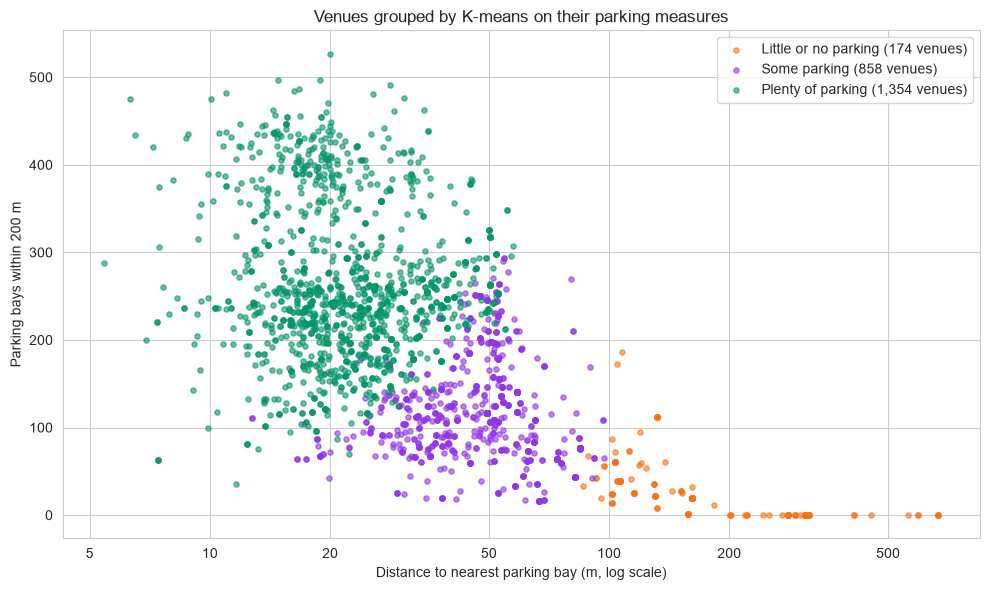

In [20]:
kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
venues_m["kmeans_group"] = kmeans_model.fit_predict(cluster_input)

# K-means numbers its groups arbitrarily, so we name them by their typical bay count.
GROUP_NAMES = ["Little or no parking", "Some parking", "Plenty of parking"]
group_order = venues_m.groupby("kmeans_group")["bays_within_200m"].median().sort_values().index
venues_m["parking_group"] = venues_m["kmeans_group"].map(dict(zip(group_order, GROUP_NAMES)))

profile = venues_m.groupby("parking_group").agg(
    venues=("seats", "size"),
    median_nearest_bay_m=("nearest_bay_m", "median"),
    median_bays_within_100m=("bays_within_100m", "median"),
    median_bays_within_200m=("bays_within_200m", "median"),
).loc[GROUP_NAMES].round(0).astype(int)
print(profile.to_string())

print("\nK-means groups compared with the score categories (number of venues):")
comparison = pd.crosstab(venues_m["parking_group"], venues_m["access_category"])
print(comparison.loc[GROUP_NAMES, ["Low", "Moderate", "High"]].to_string())

GROUP_COLOURS = dict(zip(GROUP_NAMES, [ORANGE, PURPLE, GREEN]))
plt.figure(figsize=(10, 6))
for name, colour in GROUP_COLOURS.items():
    group = venues_m[venues_m["parking_group"] == name]
    plt.scatter(group["nearest_bay_m"], group["bays_within_200m"], s=14, alpha=0.6,
                color=colour, label=f"{name} ({len(group):,} venues)")
plt.xscale("log")
distance_ticks = [5, 10, 20, 50, 100, 200, 500]
plt.xticks(distance_ticks, [str(tick) for tick in distance_ticks])
plt.title("Venues grouped by K-means on their parking measures")
plt.xlabel("Distance to nearest parking bay (m, log scale)")
plt.ylabel("Parking bays within 200 m")
plt.legend()
plt.tight_layout()
plt.show()

<div class="usecase-body">
<b>What this shows:</b> what a typical venue in each K-means group looks like, how the groups compare with the rule-based categories from section 5.3, and where each venue falls on the two main measures.
</div>

<div class="usecase-body">
<b>Why it matters:</b> K-means had no access to the score, yet it agrees with it at the extremes. Every venue in the <i>Little or no parking</i> group is rated Low, and no venue in the <i>Plenty of parking</i> group is. That gives us confidence the score is measuring something real. The two methods differ in the middle, because the score splits venues into thirds while K-means looks for natural breaks. With a silhouette score of around 0.4 the groups overlap somewhat, which is normal for measures that change gradually rather than in steps.
</div>

<div id="sub-6-2" class="usecase-sub-section-heading"><b>6.2. Dining hotspots with DBSCAN</b></div>

<div class="usecase-body">DBSCAN groups points that are packed closely together and labels scattered points as noise. Run on venue locations, it finds <b>dining hotspots</b>: places where at least 15 venues sit within 75 m of one another. Unlike K-means, it does not need to be told how many groups to find.</div>

<div class="usecase-body">For each hotspot we then add up its seats, count the parking bays within 100 m of any of its venues, and divide one by the other. The result, <b>seats per bay</b>, shows how many seats compete for each nearby bay.</div>

In [21]:
HOTSPOT_RADIUS_M = 75     # how close venues must be to count as neighbours
HOTSPOT_MIN_VENUES = 15   # how many neighbours it takes to form a hotspot

coordinates = np.column_stack([venues_m.geometry.x, venues_m.geometry.y])   # metres
dbscan_model = DBSCAN(eps=HOTSPOT_RADIUS_M, min_samples=HOTSPOT_MIN_VENUES)
venues_m["hotspot"] = dbscan_model.fit_predict(coordinates)   # -1 means "not in a hotspot"

in_hotspot = venues_m["hotspot"] != -1
hotspot_score = silhouette_score(coordinates[in_hotspot], venues_m.loc[in_hotspot, "hotspot"])

print(f"Hotspots found          : {venues_m.loc[in_hotspot, 'hotspot'].nunique()}")
print(f"Venues inside a hotspot : {in_hotspot.sum():,} ({in_hotspot.mean():.0%})")
print(f"Silhouette score (hotspot venues only): {hotspot_score:.2f}")

Hotspots found          : 30
Venues inside a hotspot : 1,337 (56%)
Silhouette score (hotspot venues only): 0.32


<div class="usecase-body">
<b>What this shows:</b> how many hotspots DBSCAN found, how many venues fall inside them, and how well separated they are.
</div>

<div class="usecase-body">
<b>Why it matters:</b> the silhouette score leaves out the venues labelled as noise, so it flatters the result a little. It also penalises the long, street-shaped hotspots that DBSCAN is good at finding, so a middling value is expected here and does not mean the hotspots are poor.
</div>

In [22]:
# Pull a street name out of addresses such as "Shop 3, 201 Spring Street MELBOURNE VIC 3000".
STREET_PATTERN = re.compile(
    r"((?:[A-Z][A-Za-z']*\s){1,2}(?:Street|Road|Lane|Place|Parade|Avenue|Boulevard"
    r"|Way|Walk|Promenade|Drive|Square|Arcade|Wharf|Esplanade))\b"
)


def street_name(address):
    match = STREET_PATTERN.search(address)
    return match.group(1) if match else None


def most_common(values):
    values = values.dropna()
    return values.mode()[0] if len(values) else "-"


venues_m["street"] = venues_m["business_address"].map(street_name)
hotspot_venues = venues_m[in_hotspot]

# Pair every hotspot venue with every bay within 100 m, then count each bay once per hotspot.
venue_positions, bay_positions = bays_m.sindex.query(
    hotspot_venues.geometry, predicate="dwithin", distance=SHORT_WALK_M)
nearby_bays = pd.DataFrame({
    "hotspot": hotspot_venues["hotspot"].to_numpy()[venue_positions],
    "bay": bay_positions,
})

hotspots = hotspot_venues.groupby("hotspot").agg(
    area=("area", most_common),
    main_street=("street", most_common),
    venues=("seats", "size"),
    seats=("seats", "sum"),
)
hotspots["bays_within_100m"] = nearby_bays.groupby("hotspot")["bay"].nunique()
hotspots["bays_within_100m"] = hotspots["bays_within_100m"].fillna(0).astype(int)

# A hotspot with no nearby bays has no ratio to show.
hotspots["seats_per_bay"] = (hotspots["seats"] / hotspots["bays_within_100m"].replace(0, np.nan)).round(1)
hotspots = hotspots.sort_values("seats_per_bay", ascending=False, na_position="first")

no_bays = (hotspots["bays_within_100m"] == 0).sum()
print(f"{no_bays} hotspots have no parking bay within {SHORT_WALK_M} m of any of their venues.")
print(f"In the others, seats per bay range from {hotspots['seats_per_bay'].min():.0f} "
      f"to {hotspots['seats_per_bay'].max():.0f} (typical: {hotspots['seats_per_bay'].median():.0f}).")
best_supplied = hotspots.dropna(subset=["seats_per_bay"]).tail(5)
print("Lowest ratios: " + "; ".join(
    f"{row.main_street}, {row.area} ({row.seats_per_bay:.0f})" for row in best_supplied.itertuples()))
print("\nThe ten hotspots under the most pressure:")

hotspots.reset_index(drop=True).head(10)

2 hotspots have no parking bay within 100 m of any of their venues.
In the others, seats per bay range from 5 to 201 (typical: 18).
Lowest ratios: Errol Street, North Melbourne (7); Collins Street, Melbourne (CBD) (7); Lygon Street, Carlton (6); Elizabeth Street, Melbourne (CBD) (6); Little Collins Street, Melbourne (CBD) (5)

The ten hotspots under the most pressure:


,area,main_street,venues,seats,bays_within_100m,seats_per_bay
0,Southbank,Convention Centre Place,15,2792,0,NaN
1,Southbank,Whiteman Street,33,6886,0,NaN
2,Southbank,Southgate Avenue,18,2820,14,201.4
3,Melbourne (CBD),Lonsdale Street,42,3658,21,174.2
4,Docklands,Docklands Drive,19,1720,10,172.0
5,Melbourne (CBD),Swanston Street,15,2095,26,80.6
6,Melbourne (CBD),Lonsdale Street,18,1975,34,58.1
7,Melbourne (CBD),Flinders Lane,43,6473,126,51.4
8,Melbourne (CBD),QV Square,28,2240,56,40.0
9,Melbourne (CBD),Bourke Street,369,30015,868,34.6


<div class="usecase-body">
<b>What this shows:</b> the best supplied hotspots, then the ten under the most parking pressure, named by their area and most common street. Hotspots with no bays nearby come first.
</div>

<div class="usecase-body">
<b>Why it matters:</b> this moves the analysis from single venues to whole precincts, which is the level at which parking and transport decisions are made. A hotspot with a hundred or more seats per bay can only work if most visitors walk, cycle or use public transport.
</div>

<div id="section-7" class="usecase-section-heading"><b>7. Mapping the results</b></div>

<div class="usecase-body">Maps make the pattern easy to read, but they have to be built carefully. Adding a separate marker for each of more than 2,000 venues would make the notebook very large and slow to open, so the city map stores all venues in a single GeoJSON layer instead.</div>

<div id="sub-7-1" class="usecase-sub-section-heading"><b>7.1. Parking access across the city</b></div>

<div class="usecase-body">Each circle is a venue, coloured by its parking access category. Blue outlines mark the DBSCAN hotspots, and the legend in the bottom left explains the colours. Clicking a venue or hovering over a hotspot shows its details, and the layer control in the top right switches each layer on or off.</div>

In [23]:
# OpenStreetMap blocks tiles requested from inside a notebook ("403 Access blocked"),
# so both maps use Esri's free light grey basemap, which needs no API key.
MAP_TILES = ("https://server.arcgisonline.com/ArcGIS/rest/services/Canvas/"
             "World_Light_Gray_Base/MapServer/tile/{z}/{y}/{x}")
MAP_ATTR = "Tiles &copy; Esri"


def base_map(location, zoom_start):
    """Create a folium map on the light grey basemap."""
    new_map = folium.Map(location=location, zoom_start=zoom_start, tiles=None, max_zoom=18)
    # The basemap has no detail past zoom level 16, so closer zooms enlarge those tiles.
    folium.TileLayer(MAP_TILES, attr=MAP_ATTR, name="Basemap", control=False,
                     max_native_zoom=16, max_zoom=18).add_to(new_map)
    return new_map


def add_legend(folium_map, title, entries):
    """Add a fixed legend box to a map.

    entries is a list of (colour, label, shape), where shape is "dot" for a filled
    circle or "ring" for an outline.
    """
    rows = ""
    for colour, label, shape in entries:
        swatch = f"background:{colour};" if shape == "dot" else f"border:2px solid {colour};"
        rows += (f'<div style="margin-top:4px;"><span style="display:inline-block;width:12px;'
                 f'height:12px;box-sizing:border-box;border-radius:50%;margin-right:8px;'
                 f'vertical-align:middle;{swatch}"></span>{label}</div>')
    folium_map.get_root().html.add_child(folium.Element(
        f'<div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;'
        f'color:{DARK};padding:8px 12px;border-radius:4px;font-size:13px;'
        f'box-shadow:0 1px 4px rgba(0,0,0,.3);"><b>{title}</b>{rows}</div>'
    ))


map_centre = [venues["latitude"].median(), venues["longitude"].median()]
access_map = base_map(map_centre, zoom_start=14)

# Hotspots first, so the venue circles are drawn on top and stay clickable.
# Each outline wraps a group of venues, 30 m wider than the venues themselves.
outlines = hotspot_venues.dissolve(by="hotspot").convex_hull.buffer(30, resolution=4)
hotspot_layer = gpd.GeoDataFrame(
    hotspots.assign(
        seats_per_bay=hotspots["seats_per_bay"].map(
            lambda value: "no bays nearby" if pd.isna(value) else f"{value:.0f}")),
    geometry=outlines.reindex(hotspots.index),
    crs=CRS_METRES,
).to_crs(CRS_DEGREES)
hotspot_layer["geometry"] = hotspot_layer.geometry.set_precision(0.00001)
folium.GeoJson(
    hotspot_layer.to_json(),
    name="Dining hotspots",
    style_function=lambda feature: {"color": BLUE, "weight": 2, "fillOpacity": 0.05},
    tooltip=folium.GeoJsonTooltip(
        fields=["main_street", "area", "venues", "seats", "seats_per_bay"],
        aliases=["Hotspot", "Area", "Venues", "Seats", "Seats per bay"],
    ),
).add_to(access_map)

# Keep only the fields shown in the pop-up, and round coordinates to about 1 m,
# so the map stays small enough to open quickly.
venue_points = gpd.GeoDataFrame(
    venues_m[["trading_name", "seats", "bays_within_200m", "access_category"]].assign(
        access_score=venues_m["access_score"].round().astype(int),
        nearest_bay_m=venues_m["nearest_bay_m"].round().astype(int),
    ),
    geometry=gpd.points_from_xy(venues_m["longitude"].round(5), venues_m["latitude"].round(5)),
    crs=CRS_DEGREES,
)

# One layer per category, so each can be switched on or off.
for category, colour in CATEGORY_COLOURS.items():
    layer = venue_points[venue_points["access_category"] == category].drop(columns="access_category")
    folium.GeoJson(
        layer.to_json(),
        name=f"{category} parking access ({len(layer):,} venues)",
        marker=folium.CircleMarker(radius=4, color=colour, fill=True, fill_color=colour,
                                   fill_opacity=0.85, weight=0),
        popup=folium.GeoJsonPopup(
            fields=["trading_name", "seats", "access_score", "nearest_bay_m", "bays_within_200m"],
            aliases=["Venue", "Seats", "Access score", "Nearest bay (m)", "Bays within 200 m"],
        ),
    ).add_to(access_map)

add_legend(access_map, "Parking access",
           [(colour, category, "dot") for category, colour in CATEGORY_COLOURS.items()]
           + [(BLUE, "Dining hotspot", "ring")])

folium.LayerControl().add_to(access_map)
access_map

<div class="usecase-body">
<b>What this shows:</b> every venue on one interactive map, coloured by parking access, with the dining hotspots outlined.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it turns the tables into geography. Clusters of orange circles inside a blue outline are the precincts where many seats share little parking, now visible in their real street context.
</div>

<div id="sub-7-2" class="usecase-sub-section-heading"><b>7.2. Looking up the parking near one venue</b></div>

<div class="usecase-body">This function answers the venue owner's question from the scenario. Give it a trading name and it prints the venue's parking figures and maps the venue (orange), every bay (green) and meter (purple) within 200 m. The blue circle marks the 200 m walking radius.</div>

In [24]:
def show_parking_near(venue_name, radius_m=LONGER_WALK_M):
    """Print a venue's parking figures and map the bays and meters within radius_m metres."""
    matches = venues_m[venues_m["trading_name"].str.lower() == venue_name.lower()]
    if matches.empty:
        print(f"No venue called '{venue_name}' in the {CENSUS_YEAR} census.")
        return None
    if len(matches) > 1:
        print(f"{len(matches)} venues share this name; showing the one at "
              f"{matches.iloc[0]['business_address']}.")
    venue = matches.iloc[0]

    nearby_bays = bays_m[bays_m.distance(venue.geometry) <= radius_m]
    nearby_meters = meters_m[meters_m.distance(venue.geometry) <= radius_m]

    print(f"{venue['trading_name']} ({venue['area']}), {venue['seats']:,} seats")
    print(f"Parking access : {venue['access_category']} (score {venue['access_score']:.0f} out of 100)")
    print(f"Nearest bay    : {venue['nearest_bay_m']:.0f} m, {venue['nearest_bay_street']}")
    print(f"Within {radius_m} m   : {len(nearby_bays)} bays and {len(nearby_meters)} meters")

    location = [venue["latitude"], venue["longitude"]]
    lookup_map = base_map(location, zoom_start=17)
    folium.Circle(location, radius=radius_m, color=BLUE, weight=1, fill=False).add_to(lookup_map)
    for bay in nearby_bays.itertuples():
        folium.CircleMarker([bay.latitude, bay.longitude], radius=3, color=GREEN,
                            fill=True, fill_opacity=0.8, weight=0).add_to(lookup_map)
    for meter in nearby_meters.itertuples():
        folium.CircleMarker([meter.latitude, meter.longitude], radius=5, color=PURPLE,
                            fill=True, fill_opacity=0.9, tooltip=meter.meter_location).add_to(lookup_map)
    folium.CircleMarker(location, radius=9, color=DARK, weight=2, fill=True, fill_color=ORANGE,
                        fill_opacity=1, tooltip=venue["trading_name"]).add_to(lookup_map)
    add_legend(lookup_map, venue["trading_name"], [
        (ORANGE, "Venue", "dot"),
        (GREEN, "Parking bay", "dot"),
        (PURPLE, "Parking meter", "dot"),
        (BLUE, f"{radius_m} m walking radius", "ring"),
    ])
    return lookup_map


show_parking_near("Yarra Botanica")

Yarra Botanica (Southbank), 684 seats
Parking access : Low (score 7 out of 100)
Nearest bay    : 86 m, Riverside Quay between Cook Street and Southgate Avenue
Within 200 m   : 33 bays and 2 meters


<div class="usecase-body">
<b>What this shows:</b> a large Southbank venue with Low parking access, its nearest bay, and every bay and meter within a two to three minute walk.
</div>

<div class="usecase-body">
<b>Why it matters:</b> it turns the city-wide analysis into something a single venue can act on. Try a venue from a well served area, such as <code>show_parking_near("Brunetti Classico Carlton")</code>, to see the difference.
</div>

<div id="conclusion" class="usecase-unnumbered-heading"><b>Conclusion</b></div>

**What we achieved in this analysis**

We combined the 2024 census records for 2,386 cafes, restaurants, pubs and bars, holding about 216,000 seats, with 29,053 on-street parking bays and 1,404 parking meters. For every venue we measured the distance to its nearest bay and counted the bays and meters within a short walk. We then combined those measures into a transparent parking access score, and used K-means and DBSCAN to find groups of venues and dining hotspots.

**What we learned from this analysis**

<div class="usecase-body">
Most venues have plenty of on-street parking close by, but the shortfall is concentrated in a few waterfront and fringe areas, and the amount of parking has no link to how big a venue is.
</div>

<div class="usecase-list">

- **Most venues have parking within a minute's walk.** A typical venue's nearest bay is 32 m away, with 48 bays within 100 m and 196 within 200 m. Only 167 venues (7%) have no bay within 100 m, and 54 have none within 200 m.
- **The shortfall is concentrated in a few areas.** All 18 venues in Port Melbourne rate Low, along with 85% in Parkville, 75% in Southbank and 72% in Docklands. At the other end, 95% of venues in West Melbourne (Residential) and 89% in Carlton rate High. The CBD sits in the middle, with most of its venues rated Moderate.
- **Bigger venues do not get more parking.** Venue size is essentially unrelated to parking supply, with a correlation of -0.09 against the number of bays within 200 m. As a result, 114 of the 240 largest venues (187 seats or more) have Low access. That is 48%, compared with 29% of all venues. Most of them are in Southbank, the CBD and Docklands.
- **Clustering backs up the score.** K-means never saw the score, yet it found a distinct group of 174 venues with almost no parking nearby, and every one of them is rated Low.
- **Some dining precincts depend almost entirely on other transport.** DBSCAN found 30 dining hotspots holding 56% of all venues. Two of them, both in Southbank around Whiteman Street and Convention Centre Place, have no parking bay within 100 m at all. The busiest of the rest, around Southgate Avenue, part of Lonsdale Street and Docklands Drive, have more than 170 seats for every nearby bay, compared with a typical 18. The best supplied, such as Lygon Street in Carlton and Errol Street in North Melbourne, have fewer than 10.

</div>

**Limitations**

<div class="usecase-body">
The parking data shows where bays are, not whether they are free, what time limits apply, or whether they are kept for permits or loading. Off-street car parks, which serve many large venues, are not included. Distances are straight lines, and the parking snapshot (2025 to 2026) is slightly newer than the 2024 venue census.
</div>

**Observations for further opportunities**

<div class="usecase-body">
The same steps work for any question that compares demand with supply when both have coordinates: turn the records into one row per place, convert them to a metre grid, and count what lies within walking distance.
</div>

<div class="usecase-list">

- Use the City's on-street parking sensor data to measure how often nearby bays are actually free at meal times.
- Add off-street car parks and parking restrictions for a fuller picture of supply.
- Include tram, train and bus stops, since precincts with little parking rely on public transport.
- Repeat the analysis for earlier census years to see whether venues are moving towards or away from parking.

</div>